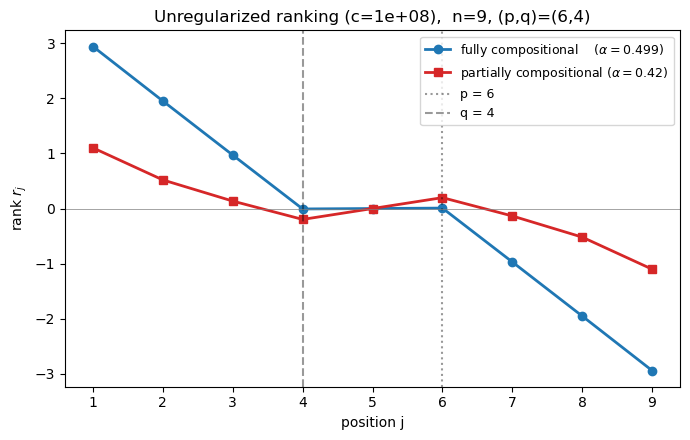

In [12]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

# ----------------------------------------------------
# Compare fully vs partially compositional ranking
# (no regularization: large c_reg)
# ----------------------------------------------------
n, p, q    = 9, 6, 4
k_s, k_d   = 1.0, 0.0
c_reg      = 1e8                 # effectively no regularization

alpha_full    = 0.499            # fully compositional
alpha_partial = 0.42             # partially compositional

k_o_full    = alpha_full    * (k_s - k_d)
k_o_partial = alpha_partial * (k_s - k_d)

sim_full    = Ranking_exp(n=n, k_o=k_o_full,    k_s=k_s, k_d=k_d,
                          p=p, q=q, c_reg=c_reg)
sim_partial = Ranking_exp(n=n, k_o=k_o_partial, k_s=k_s, k_d=k_d,
                          p=p, q=q, c_reg=c_reg)

r_full    = sim_full.calc_rank_analytic()
r_partial = sim_partial.calc_rank_analytic()

x = np.arange(1, n + 1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x, r_full,    marker='o', color='#1f77b4', lw=2,
        label=fr'fully compositional    ($\alpha={alpha_full}$)')
ax.plot(x, r_partial, marker='s', color='#d62728', lw=2,
        label=fr'partially compositional ($\alpha={alpha_partial}$)')

ax.axvline(p, color='k', ls=':',  alpha=0.4, label=f'p = {p}')
ax.axvline(q, color='k', ls='--', alpha=0.4, label=f'q = {q}')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('position j')
ax.set_ylabel(r'rank $r_j$')
ax.set_title(fr'Unregularized ranking (c={c_reg:.0e}),  n={n}, (p,q)=({p},{q})')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()
fig.savefig("figure_4a.pdf", bbox_inches="tight")

# Figure 4c
## This uses the inverse solution for now

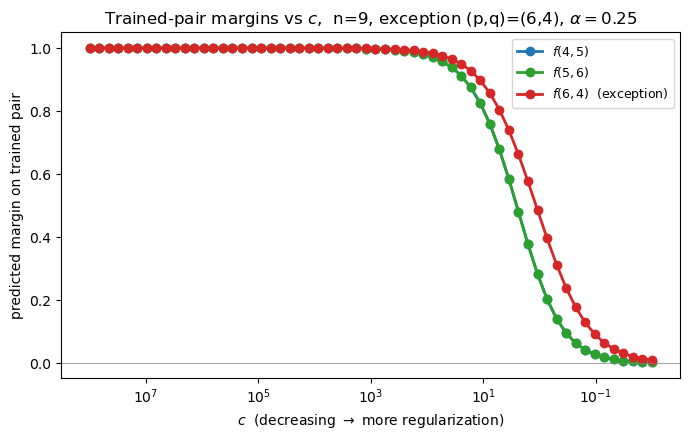

In [15]:
import sys, os, io, contextlib
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

# ----------------------------------------------------
# Margin vs regularization for TRAINED pairs
# (use f_j_k, not r_i - r_j)
# ----------------------------------------------------
n, p, q       = 9, 6, 4
k_s, k_d      = 1.0, 0.0
alpha_prime   = 0.25                       # partially compositional
k_o           = alpha_prime * (k_s - k_d)

pairs = [(4, 5), (5, 6), (6, 4)]           # all trained pairs
c_reg_vals = np.logspace(-2, 8, 60)

margins = {pair: np.zeros_like(c_reg_vals) for pair in pairs}
for k, cr in enumerate(c_reg_vals):
    # suppress the __init__ prints
    with contextlib.redirect_stdout(io.StringIO()):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                          p=p, q=q, c_reg=cr)
    for (i, j) in pairs:
        margins[(i, j)][k] = sim.f_j_k(i, j)    # kernel prediction on trained pair

# ----------------------------------------------------
# Plot
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ['#1f77b4', '#2ca02c', '#d62728']
for (pair, color) in zip(pairs, colors):
    i, j = pair
    label = fr'$f({i},{j})$'
    if pair == (p, q):
        label += '  (exception)'
    ax.plot(c_reg_vals, margins[pair], marker='o', color=color,
            lw=2, label=label)

ax.set_xscale('log')
ax.invert_xaxis()                          # decreasing c -> more regularization
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel(r'$c$  (decreasing $\rightarrow$ more regularization)')
ax.set_ylabel('predicted margin on trained pair')
ax.set_title(fr'Trained-pair margins vs $c$,  n={n}, exception (p,q)=({p},{q}), $\alpha={alpha_prime}$')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()
fig.savefig("figure_4c.pdf", bbox_inches="tight")

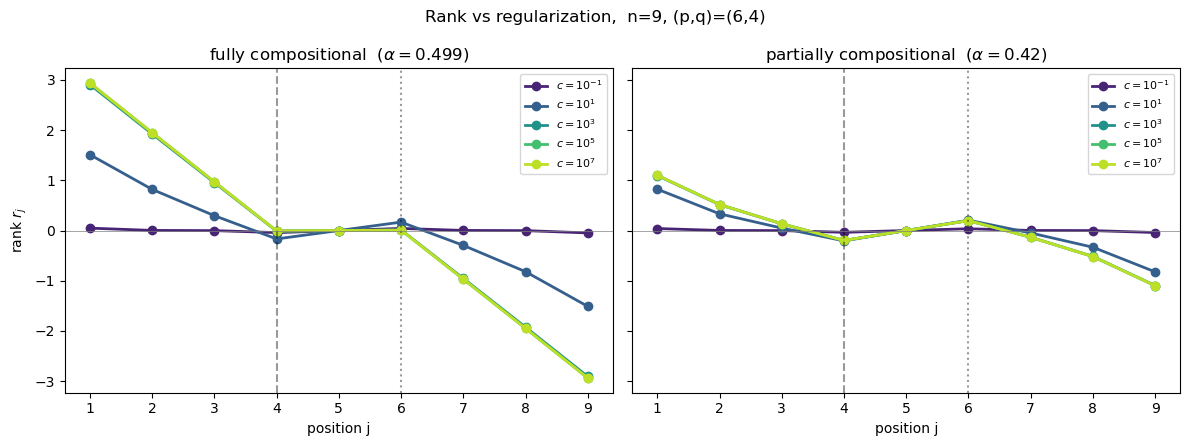

In [17]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

# ----------------------------------------------------
# Compare fully vs partially compositional ranking
# across 5 regularization settings
# ----------------------------------------------------
n, p, q    = 9, 6, 4
k_s, k_d   = 1.0, 0.0

alpha_full    = 0.499     # fully compositional
alpha_partial = 0.42      # partially compositional

c_reg_vals = np.logspace(-1, 7, 5)     # 5 log-spaced c values: 1e-1, 1e1, 1e3, 1e5, 1e7

alpha_settings = [
    ('fully compositional',    alpha_full),
    ('partially compositional', alpha_partial),
]

x = np.arange(1, n + 1)
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(c_reg_vals)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (label, ap) in zip(axes, alpha_settings):
    k_o = ap * (k_s - k_d)
    for cr, col in zip(c_reg_vals, cmap):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                          p=p, q=q, c_reg=cr)
        r = sim.calc_rank_analytic()
        ax.plot(x, r, marker='o', color=col, lw=2,
                label=fr'$c=10^{{{int(np.log10(cr))}}}$')
    ax.axvline(p, color='k', ls=':',  alpha=0.4)
    ax.axvline(q, color='k', ls='--', alpha=0.4)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlabel('position j')
    ax.set_title(fr'{label}  ($\alpha={ap}$)')
    ax.legend(loc='best', fontsize=8)

axes[0].set_ylabel(r'rank $r_j$')
fig.suptitle(fr'Rank vs regularization,  n={n}, (p,q)=({p},{q})')
plt.tight_layout()
plt.show()
fig.savefig("figure_4d.pdf", bbox_inches="tight")

k_o sweep:   0%|          | 0/99 [00:00<?, ?it/s]

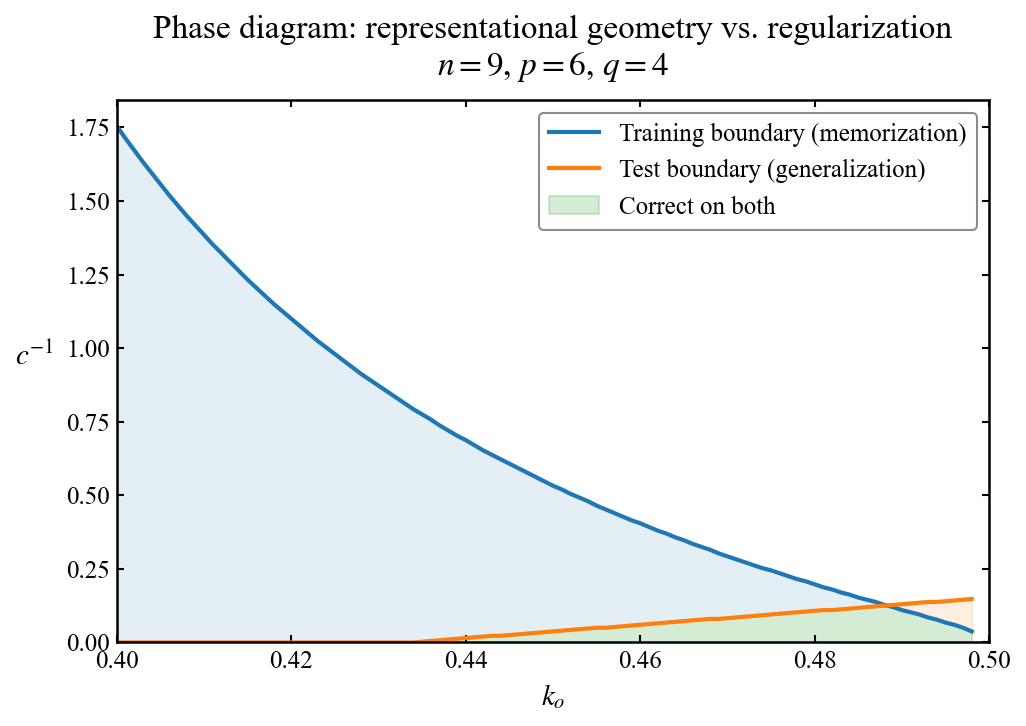

In [22]:
import sys, os, io, contextlib
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from Ranking_exp import Ranking_exp

# ------------------------- parameters -------------------------
n = 9
p = 6
q = 4
k_s = 1.0
k_d = 0.0
delta_s = k_s - k_d

k_o_vals   = np.arange(0.40, 0.499, 0.001)
c_var_vals = np.arange(1e-4, 4, 0.0025)
c_vals     = 1.0 / (c_var_vals * delta_s)

test_critical_pair  = [q - 1, p]      # (q-1, p): test generalization margin
train_critical_pair = [q, q + 1]      # (q, q+1): training margin

# ------------------------- sweep -------------------------
breaking_reg_test  = []
breaking_reg_train = []

for k_o in tqdm(k_o_vals, desc='k_o sweep'):

    # -- find smallest c_var where TEST margin flips negative --
    test_flag = False
    for i, cr in enumerate(c_vals):
        with contextlib.redirect_stdout(io.StringIO()):
            sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                              p=p, q=q, c_reg=cr)
        if sim.f_j_k(test_critical_pair[0], test_critical_pair[1]) < 0:
            breaking_reg_test.append(c_var_vals[i])
            test_flag = True
            break
    if not test_flag:
        breaking_reg_test.append(0)

    # -- find smallest c_var where TRAIN margin flips negative --
    train_flag = False
    for i, cr in enumerate(c_vals):
        with contextlib.redirect_stdout(io.StringIO()):
            sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                              p=p, q=q, c_reg=cr)
        if sim.f_j_k(train_critical_pair[0], train_critical_pair[1]) < 0:
            breaking_reg_train.append(c_var_vals[i])
            train_flag = True
            break
    if not train_flag:
        breaking_reg_train.append(0)

# ------------------------- plot -------------------------
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'font.size': 12,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
})

train   = np.array(breaking_reg_train)
test    = np.array(breaking_reg_test)
overlap = np.minimum(train, test)

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

ax.plot(k_o_vals, train, linewidth=2, color='#1f77b4',
        label='Training boundary (memorization)')
ax.plot(k_o_vals, test,  linewidth=2, color='#ff7f0e',
        label='Test boundary (generalization)')

ax.fill_between(k_o_vals, overlap, train, alpha=0.12, color='#1f77b4')
ax.fill_between(k_o_vals, overlap, test,  alpha=0.12, color='#ff7f0e')
ax.fill_between(k_o_vals, 0, overlap, alpha=0.20, color='#2ca02c',
                label='Correct on both')

ax.set_xlabel(r'$k_o$', fontsize=14)
ax.set_ylabel(r'$c^{-1}$', fontsize=14, rotation=0, labelpad=15)
ax.set_title(
    f'Phase diagram: representational geometry vs. regularization\n'
    f'$n={n}$, $p={p}$, $q={q}$',
    fontsize=16, pad=12
)
ax.legend(fontsize=12, framealpha=0.9, edgecolor='gray', loc='upper right')

ax.set_xlim(0.40, 0.50)
ax.set_ylim(bottom=0)
ax.grid(False)

fig.tight_layout()
plt.show()
fig.savefig("figure_4e.pdf", bbox_inches="tight")